In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

In [2]:
px = yf.download(["GLD", "USO"], start="2006-05-23", end="2012-04-09", auto_adjust=True)["Close"].dropna()[["GLD", "USO"]]

[*********************100%***********************]  2 of 2 completed


In [4]:
px.head()

Ticker,GLD,USO
Date,,
2006-05-23,66.379997,542.159973
2006-05-24,64.059998,528.799988
2006-05-25,64.699997,542.400024
2006-05-26,65.099998,542.000000
2006-05-30,65.110001,546.559998


In [5]:
rets = px.pct_change()

In [17]:
def hedge(a, b):
    return sm.OLS(a, sm.add_constant(b)).fit().params.iloc[1]

def halflife(s):
    s = s.dropna()                  
    d, l = s.diff().iloc[1:], s.shift(1).iloc[1:]
    lam = sm.OLS(d, sm.add_constant(l)).fit().params.iloc[1]
    return -np.log(2) / lam if lam < 0 else np.inf
    
def backtest(name, s, pos_fn):
    hl = halflife(s)
    if not (0 < hl < 250):
        print(f"{name:<7} half-life={hl:.1f} -> no usable mean reversion, skipped")
        return
    lb = int(round(hl))
    z = (s - s.rolling(lb).mean()) / s.rolling(lb).std()
    pos = pos_fn(z)                                   # $ position in each ETF
    pnl = (pos.shift(1) * rets).sum(axis=1, min_count=2)
    gross = pos.shift(1).abs().sum(axis=1)
    ret = (pnl / gross).dropna()
    sh = np.sqrt(252) * ret.mean() / ret.std()
    print(f"{name:<7} half-life={hl:6.1f}  lookback={lb:>3}  Sharpe={sh:5.2f}  "
          f"total return={(1 + ret).prod() - 1:7.1%}  n={len(ret)}")

In [8]:
h_p = hedge(px["GLD"], px["USO"])
h_l = hedge(np.log(px["GLD"]), np.log(px["USO"]))
print(f"price hedge ratio={h_p:.3f}  log hedge ratio={h_l:.3f}")

price hedge ratio=-0.096  log hedge ratio=-0.469


In [9]:
s_price = px["GLD"] - h_p * px["USO"]
s_log   = np.log(px["GLD"]) - h_l * np.log(px["USO"])
s_ratio = px["GLD"] / px["USO"]

<Axes: xlabel='Date'>

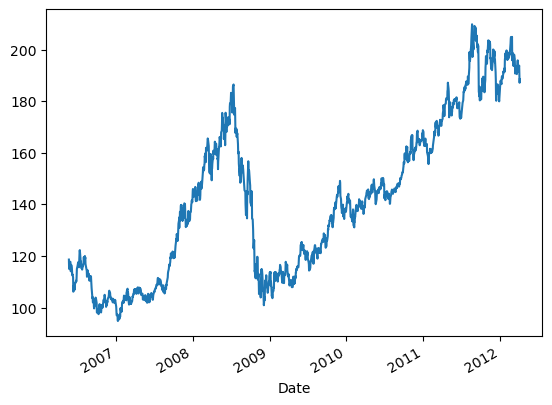

In [10]:
s_price.plot()

In [11]:
print("coint p, prices    :", round(coint(px["GLD"], px["USO"], maxlag=1, autolag=None)[1], 3))
print("coint p, log prices:", round(coint(np.log(px["GLD"]), np.log(px["USO"]), maxlag=1, autolag=None)[1], 3))
print("ADF p, ratio       :", round(adfuller(s_ratio, maxlag=1, autolag=None)[1], 3))

coint p, prices    : 0.92
coint p, log prices: 0.866
ADF p, ratio       : 0.782


In [14]:
backtest("price", s_price, lambda z: pd.DataFrame({"GLD": -z * px["GLD"], "USO": h_p * z * px["USO"]}))
backtest("log",   s_log,   lambda z: pd.DataFrame({"GLD": -z,            "USO": h_l * z}))
backtest("ratio", s_ratio, lambda z: pd.DataFrame({"GLD": -z,            "USO": z}))

price   half-life=463.7 -> no usable mean reversion, skipped
log     half-life=322.7 -> no usable mean reversion, skipped
ratio   half-life=545.5 -> no usable mean reversion, skipped


In [15]:
w = 252
beta = px["GLD"].rolling(w).cov(px["USO"]) / px["USO"].rolling(w).var()
s = px["GLD"] - beta * px["USO"]

In [20]:
backtest("dynamic", s, lambda z: pd.DataFrame({"GLD": -z * px["GLD"], "USO": beta * z * px["USO"]}))
print(beta.describe())

dynamic half-life=inf -> no usable mean reversion, skipped
count    1229.000000
mean        0.011076
std         0.147110
min        -0.304013
25%        -0.052511
50%         0.018955
75%         0.090458
max         0.310777
dtype: float64


In [19]:
print(s.corr(px["GLD"]))

0.7254501623943004


In [21]:
import numpy as np
import pandas as pd

lb = 20
rets = px.pct_change()

def run(a_name, b_name, flip=False):
    a, b = px[a_name], px[b_name]
    beta   = a.rolling(lb).cov(b) / b.rolling(lb).var()      # slope of a on b
    spread = a - beta * b
    z      = (spread - spread.rolling(lb).mean()) / spread.rolling(lb).std()
    units  = z if flip else -z

    pos = pd.DataFrame({a_name: units * a, b_name: -beta * units * b})
    pnl   = (pos.shift(1) * rets[[a_name, b_name]]).sum(axis=1, min_count=2)
    gross = pos.shift(1).abs().sum(axis=1)
    ret   = (pnl / gross).dropna()

    chk  = units.shift(1) * (a.diff() - beta.shift(1) * b.diff())
    both = pd.concat([pnl, chk], axis=1).dropna()
    diff = (both.iloc[:, 0] - both.iloc[:, 1]).abs().max()

    sharpe = np.sqrt(252) * ret.mean() / ret.std()
    apr = (1 + ret).prod() ** (252 / len(ret)) - 1
    tag = "flipped" if flip else "mean-rev"
    print(f"{a_name} on {b_name}, {tag:<8}  APR={apr:6.1%}  Sharpe={sharpe:5.2f}  "
          f"check diff={diff:.1e}  n={len(ret)}")

for a_, b_ in [("GLD", "USO"), ("USO", "GLD")]:
    for flip in (False, True):
        run(a_, b_, flip)

GLD on USO, mean-rev  APR=-12.8%  Sharpe=-0.70  check diff=6.4e-14  n=1441
GLD on USO, flipped   APR= 11.3%  Sharpe= 0.70  check diff=6.4e-14  n=1441
USO on GLD, mean-rev  APR= 10.7%  Sharpe= 0.58  check diff=4.0e-13  n=1441
USO on GLD, flipped   APR=-13.8%  Sharpe=-0.58  check diff=4.0e-13  n=1441


In [22]:
for lb in (10, 20, 40, 60, 120, 252):
    run("USO", "GLD")

USO on GLD, mean-rev  APR=  0.5%  Sharpe= 0.14  check diff=4.0e-13  n=1461
USO on GLD, mean-rev  APR= 10.7%  Sharpe= 0.58  check diff=4.0e-13  n=1441
USO on GLD, mean-rev  APR=  0.4%  Sharpe= 0.12  check diff=3.7e-13  n=1401
USO on GLD, mean-rev  APR= -9.4%  Sharpe=-0.36  check diff=3.0e-13  n=1361
USO on GLD, mean-rev  APR=-16.3%  Sharpe=-0.77  check diff=3.3e-13  n=1241
USO on GLD, mean-rev  APR=-18.9%  Sharpe=-0.82  check diff=3.7e-13  n=977
